In [1]:
# Install if needed
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import nltk
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("CanadaPolitics.csv")

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.360005e+09,298,self.CanadaPolitics,17vq8n,Marc Garneau Reddit AMA,marcgarneaump,338,40,525,http://www.reddit.com/r/CanadaPolitics/comment...,...,False,self,t5_2s4gt,1360014915.0,ama,NaN,True,t3_17vq8n,http://www.reddit.com/r/CanadaPolitics/comment...,NaN
1,1.366311e+09,265,self.CanadaPolitics,1cmf4t,"AMA Request: Justin Trudeau, new leader of the...",mslyndseykay,312,47,39,http://www.reddit.com/r/CanadaPolitics/comment...,...,False,self,t5_2s4gt,False,NaN,NaN,True,t3_1cmf4t,http://www.reddit.com/r/CanadaPolitics/comment...,NaN
2,1.354122e+09,245,self.CanadaPolitics,13xvsu,"I am Preston Manning, Ask Me Anything",PrestonManning,298,53,290,http://www.reddit.com/r/CanadaPolitics/comment...,...,False,self,t5_2s4gt,False,ama,NaN,True,t3_13xvsu,http://www.reddit.com/r/CanadaPolitics/comment...,NaN
3,1.360171e+09,211,self.CanadaPolitics,180as8,Do you agree with Canada's decision to ban the...,NaN,237,26,269,http://www.reddit.com/r/CanadaPolitics/comment...,...,False,self,t5_2s4gt,1361199010.0,NaN,NaN,True,t3_180as8,http://www.reddit.com/r/CanadaPolitics/comment...,NaN
4,1.374695e+09,212,huffingtonpost.ca,1iz6ju,Justin Trudeau: Marijuana Should Be Legal In C...,talkingheads,240,28,240,http://www.reddit.com/r/CanadaPolitics/comment...,...,False,http://e.thumbs.redditmedia.com/KmizDiHGc_b4Pr...,t5_2s4gt,False,NaN,pirate,False,t3_1iz6ju,http://www.huffingtonpost.ca/2013/07/24/justin...,NaN


In [5]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [9]:
print(df.columns.tolist())

['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']


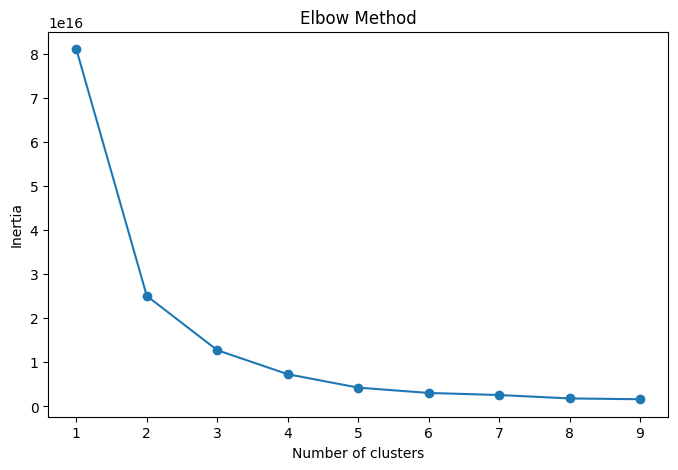

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("CanadaPolitics.csv")

# Use all numeric columns
X = df.select_dtypes(include=['number'])

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [14]:
k = 3  # choose based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished,cluster
0,1.360005e+09,298,self.CanadaPolitics,17vq8n,Marc Garneau Reddit AMA,marcgarneaump,338,40,525,http://www.reddit.com/r/CanadaPolitics/comment...,...,self,t5_2s4gt,1360014915.0,ama,NaN,True,t3_17vq8n,http://www.reddit.com/r/CanadaPolitics/comment...,NaN,2
1,1.366311e+09,265,self.CanadaPolitics,1cmf4t,"AMA Request: Justin Trudeau, new leader of the...",mslyndseykay,312,47,39,http://www.reddit.com/r/CanadaPolitics/comment...,...,self,t5_2s4gt,False,NaN,NaN,True,t3_1cmf4t,http://www.reddit.com/r/CanadaPolitics/comment...,NaN,2
2,1.354122e+09,245,self.CanadaPolitics,13xvsu,"I am Preston Manning, Ask Me Anything",PrestonManning,298,53,290,http://www.reddit.com/r/CanadaPolitics/comment...,...,self,t5_2s4gt,False,ama,NaN,True,t3_13xvsu,http://www.reddit.com/r/CanadaPolitics/comment...,NaN,1
3,1.360171e+09,211,self.CanadaPolitics,180as8,Do you agree with Canada's decision to ban the...,NaN,237,26,269,http://www.reddit.com/r/CanadaPolitics/comment...,...,self,t5_2s4gt,1361199010.0,NaN,NaN,True,t3_180as8,http://www.reddit.com/r/CanadaPolitics/comment...,NaN,2
4,1.374695e+09,212,huffingtonpost.ca,1iz6ju,Justin Trudeau: Marijuana Should Be Legal In C...,talkingheads,240,28,240,http://www.reddit.com/r/CanadaPolitics/comment...,...,http://e.thumbs.redditmedia.com/KmizDiHGc_b4Pr...,t5_2s4gt,False,NaN,pirate,False,t3_1iz6ju,http://www.huffingtonpost.ca/2013/07/24/justin...,NaN,0


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

documents = [
    "I love machine learning",
    "KMeans clustering is useful",
    "Natural language processing is interesting",
    "I love coding in Python",
    "Clustering groups similar documents"
]

vectorizer = TfidfVectorizer()
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)

X = vectorizer.fit_transform(documents)
kmeans.fit(X)

terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_inds = center.argsort()[-10:][::-1]
    top_words = [terms[ind] for ind in top_inds]
    print(top_words)


Cluster 0:
['clustering', 'is', 'kmeans', 'useful', 'similar', 'groups', 'documents', 'natural', 'processing', 'interesting']

Cluster 1:
['love', 'machine', 'learning', 'python', 'coding', 'in', 'useful', 'interesting', 'documents', 'groups']


In [20]:
print(X.shape)
print(df.shape)
print(X_pca.shape)

(5, 17)
(1000, 23)
(5, 2)
